In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

from matplotlib.pyplot import figure
from astropy.io import fits
from astropy.table import Table

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import QTable

filename_path = '../data/astraAllStarASPCAP-0.7.fits'

# this function is Lucy's way to get rid of columns that are more than 1D (pandas doesn't support that)
def Table_to_pandas(fn):
    data = fits.open(fn)
    df = QTable(data[2].data)
    cols = []
    cols_drop = []
    for i in df.columns:
        if np.size(df[i][0])==1:
            cols.append(i)
        else:
            cols_drop.append(i)
    print(cols_drop)
    return df[cols].to_pandas()

df_sdss5 = Table_to_pandas(filename_path)

df_sdss5 = df_sdss5[(df_sdss5['teff']>4500) & (df_sdss5['teff']<6500)]
df_sdss5 = df_sdss5[(df_sdss5['snr']>=200)]

['sdss5_target_flags']


In [67]:
# -------------------------------
# 1. SDSS cut on Fe/H error
# -------------------------------
df_sdss5 = df_sdss5[df_sdss5['gaia_dr3_source_id'] > 0]
df_sdss_metcut = df_sdss5[(df_sdss5['e_fe_h'] < 0.1) & (df_sdss5['e_mg_h'] < 0.1)]

In [68]:
# Ensure unique SDSS rows per Gaia source
df_sdss_metcut = df_sdss_metcut.sort_values(['snr'], ascending=False)
df_sdss_metcut = df_sdss_metcut.drop_duplicates(subset='gaia_dr3_source_id', keep='first')

In [69]:
# -------------------------------
# 2. Save Gaia IDs from SDSS cut
# -------------------------------
df_sdss_metcut['gaia_dr3_source_id'].to_csv('../data/gaia_ids_from_sdss.txt', index=False, header=False)

In [70]:
# -------------------------------
# 3. Gaia RVS flags / high SNR selection
# -------------------------------
df_gaia_rvs_flags = pd.read_csv("../data/gaia_rvs_flags.csv")

# Keep only sources with RV spectra
df_gaia_has_rvs = df_gaia_rvs_flags[df_gaia_rvs_flags['has_rvs'] == True]

# High SNR spectra
df_gaia_high_snr = df_gaia_has_rvs[df_gaia_has_rvs['rvs_spec_sig_to_noise'] > 100]

# Optional: save high SNR source_ids to VOTable, to upload to gaia archive and get their spectra
t = Table()
t['source_id'] = df_gaia_high_snr['source_id'].values
t.write('../data/gaia_high_snr_source_ids_revised.vot', format='votable', overwrite=True)

In [71]:
# lambda values are based on GAIA documentation
# Load the downloaded spectra into a dataframe called rvs_spectra_df
# Plot an example 

lambdas = np.linspace(846, 870, 2401)

t = Table.read("../data/rvs_1.xml", format="votable")

rvs_spectra_df = t.to_pandas()

rvs_spectra_df['source_id'] = rvs_spectra_df['datalinkID']
rvs_spectra_df = rvs_spectra_df[['source_id', 'flux', 'flux_error']]

In [72]:
# Keep spectra who are in sdss_metcut

stars_spectra = rvs_spectra_df[rvs_spectra_df['source_id'].isin(df_sdss_metcut['gaia_dr3_source_id'])]
print(len(stars_spectra))

2894


In [73]:
# Drop duplicates. By looking at a few examples, seemed like duplicates have the exact same spectra. so I just keep first.
# But maybe there is a better way?

stars_spectra = stars_spectra.drop_duplicates(subset='source_id', keep='first')
len(stars_spectra)

2842

In [74]:
# Keep stars from sdss_metcut who are in the spectra

stars_labels = df_sdss_metcut[df_sdss_metcut['gaia_dr3_source_id'].isin(stars_spectra['source_id'])]
print(len(stars_labels))

2842


In [75]:
stars_labels['source_id'] = stars_labels['gaia_dr3_source_id']

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/13363840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['source_id'] = stars_labels['gaia_dr3_source_id']


In [76]:
# For giants and dwarfs
most_reliable_giants = ['c_h', 'n_h', 'o_h', 'mg_h', 'al_h', 'si_h', 'mn_h', 'fe_h', 'ni_h']
reliable_giants = ['na_h', 'k_h', 'ca_h', 'co_h', 'ce_h']
most_reliable_dwarfs = ['c_h', 'mg_h', 'si_h', 'fe_h', 'ni_h']
reliable_dwarfs = ['o_h', 'al_h', 'k_h', 'ca_h', 'mn_h']

gaia_elements = ['n_h', 'mg_h', 'si_h', 's_h', 'ca_h', 'ti_h', 'cr_h', 'fe_h', 'ni_h', 'ce_h', 'nd_h']

giant_elements = [] #most_reliable + reliable
dwarf_elements = [] #most_reliable + reliable

print("*** Gaia elements in most reliable + reliable giants: ***")
for i in range(len(most_reliable_giants)):
    if most_reliable_giants[i] in gaia_elements:
        giant_elements.append(most_reliable_giants[i])

for i in range(len(reliable_giants)):
    if reliable_giants[i] in gaia_elements:
        giant_elements.append(reliable_giants[i])

print(giant_elements)

print("*** Gaia elements in most reliable + reliable dwarfs: ***")
for i in range(len(most_reliable_dwarfs)):
    if most_reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(most_reliable_dwarfs[i])

for i in range(len(reliable_dwarfs)):
    if reliable_dwarfs[i] in gaia_elements:
        dwarf_elements.append(reliable_dwarfs[i])
    
print(dwarf_elements)

*** Gaia elements in most reliable + reliable giants: ***
['n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'ce_h']
*** Gaia elements in most reliable + reliable dwarfs: ***
['mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h']


In [77]:
def abs_mag(app_mag, d):
    return app_mag - 5 * np.log10(d) + 5

In [78]:
stars_labels.head()

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,raw_ti_h,raw_e_ti_h,raw_v_h,raw_e_v_h,source_pk,v_astra,t_elapsed,t_overhead,tag,source_id
616284,59566864,,-1,1176284378646107008,449153848,82485,,-1,27021599488242790,4600993171,...,0.068,0.002236,0.679,0.001,30179,7000,NaN,0.0,,1176284378646107008
584134,78851461,,-1,3632814253855677696,295680777,107557,,-1,63050395165621231,4589587370,...,-0.258,0.001414,-0.677,0.001,29582,7000,NaN,0.0,,3632814253855677696
553552,62072620,,-1,1576936554563480832,229515664,15856,,-1,27021599489038941,4351453912,...,0.180,0.002236,0.206,0.001,27349,7000,NaN,0.0,,1576936554563480832
72755,77410298,,-1,3415237498473839872,69273930,61292,,-1,4503337322,4503337322,...,0.440,0.003162,-0.515,0.003,11281,7000,NaN,0.0,,3415237498473839872
77190,91138851,,-1,4652208111518079744,40405143,190495,,-1,63050395777593704,5909704062,...,-0.400,0.004123,0.004,0.002,222180,7000,NaN,0.0,,4652208111518079744


In [79]:
stars_labels['M_G'] = abs_mag(stars_labels['g_mag'], stars_labels['r_med_geo'])

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/1692766570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['M_G'] = abs_mag(stars_labels['g_mag'], stars_labels['r_med_geo'])


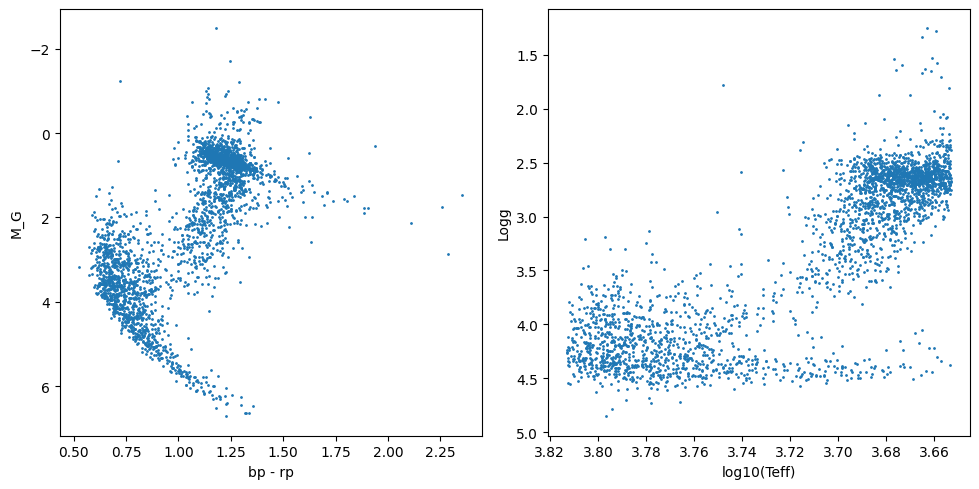

In [80]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(stars_labels['bp_mag'] - stars_labels['rp_mag'], stars_labels['M_G'], s = 1)
plt.gca().invert_yaxis()
plt.xlabel('bp - rp')
plt.ylabel('M_G')

plt.subplot(1,2,2)
plt.scatter(np.log10(stars_labels['teff']), stars_labels['logg'], s = 1)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('log10(Teff)')
plt.ylabel('Logg')

plt.tight_layout()

(0.0, 1.0)

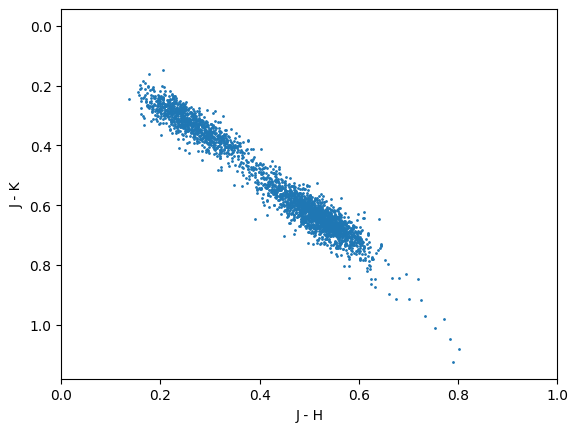

In [81]:
plt.scatter(stars_labels['j_mag'] - stars_labels['h_mag'], stars_labels['j_mag'] - stars_labels['k_mag'], s = 1)
plt.gca().invert_yaxis()
plt.xlabel('J - H')
plt.ylabel('J - K')
plt.xlim(0,1)

In [17]:
giants_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
giants_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]
#giant_labels = stars_labels[giants_label_names]
giant_labels = stars_labels
giants_df = stars_spectra.merge(giant_labels, on='source_id', how='inner')
giants_df = giants_df[(giants_df['logg'] > 1.5) & (giants_df['logg'] < 3.5)]
giants_df = giants_df[giants_df['e_fe_h'] < 0.1]
giants_df = giants_df[giants_df['e_mg_h'] < 0.1]
giants_df = giants_df[giants_df['e_si_h'] < 0.1]
giants_df = giants_df[giants_df['e_ni_h'] < 0.1]
giants_df = giants_df[giants_df['e_ca_h'] < 0.1]
giants_df = giants_df[giants_df['e_ce_h'] < 0.1]
print("number of giants = ", len(giants_df))
print(giants_label_names)

for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h', 'ce_h']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = giants_df[p].isna() | giants_df[p].astype(str).isin(['--', 'masked', '<Masked>']) | giants_df[err_col].isna() | giants_df[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = giants_df[~mask]
    med = np.median(stars_masked[p])
    giants_df.loc[mask, p] = med
    giants_df.loc[mask, err_col] = 9999

#giants_df.to_pickle('../data/giants_rel_most_rel.pkl')

number of giants =  1667
['source_id', 'teff', 'e_teff', 'logg', 'e_logg', 'n_h', 'e_n_h', 'mg_h', 'e_mg_h', 'si_h', 'e_si_h', 'fe_h', 'e_fe_h', 'ni_h', 'e_ni_h', 'ca_h', 'e_ca_h', 'ce_h', 'e_ce_h']


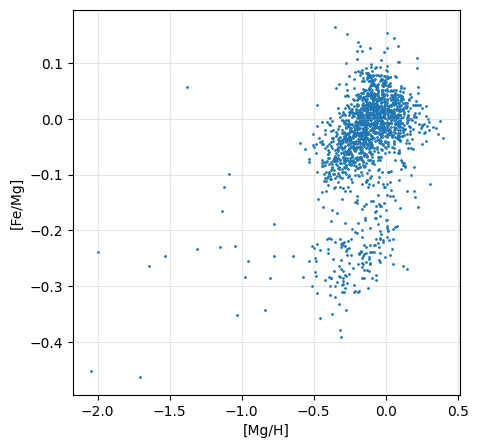

In [18]:
plt.figure(figsize=(5,5))
plt.scatter(giants_df['mg_h'], giants_df['fe_h'] - giants_df['mg_h'], s = 1)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid('True', alpha = 0.3)

KeyError: 'abs_g_mag'

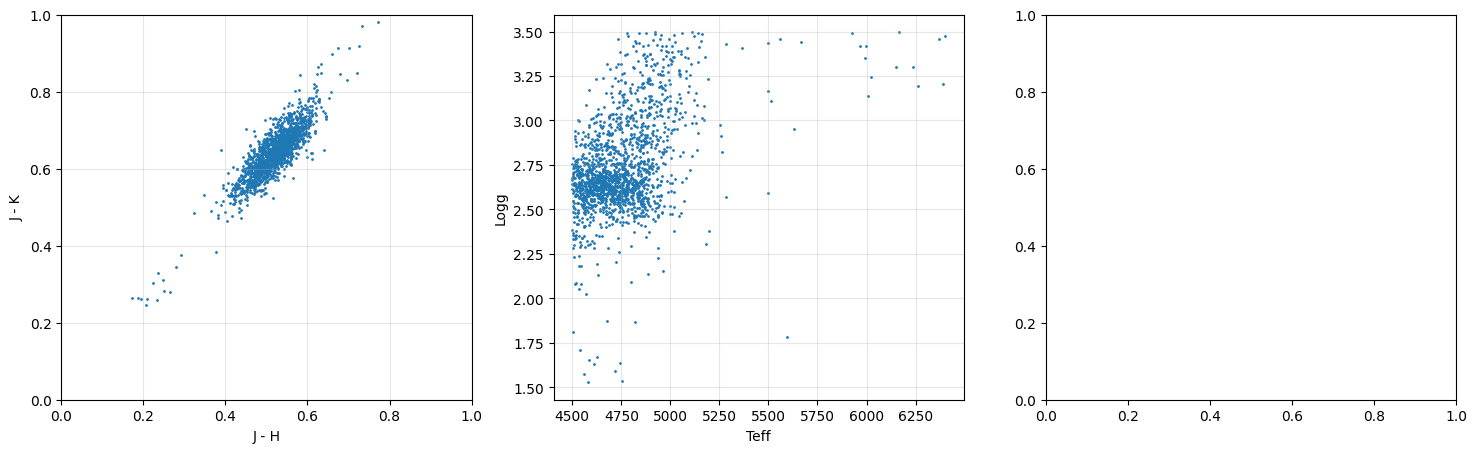

In [19]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.scatter(giants_df['j_mag'] - giants_df['h_mag'], giants_df['j_mag'] - giants_df['k_mag'], s = 1)
plt.xlabel('J - H')
plt.ylabel('J - K')
plt.xlim(0,1)
plt.ylim(0,1)
plt.grid('True', alpha = 0.3)

plt.subplot(1,3,2)
plt.scatter(giants_df['teff'], giants_df['logg'], s = 1)
plt.xlabel('Teff')
plt.ylabel('Logg')
plt.grid('True', alpha = 0.3)

plt.subplot(1,3,3)
plt.scatter(giants_df['bp_mag'] - giants_df['rp_mag'], giants_df['abs_g_mag'], s = 1)
plt.xlabel('bp - rp')
plt.ylabel('M_G')
plt.grid('True', alpha = 0.3)

plt.tight_layout()

In [20]:
dwarfs_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg']
dwarfs_label_names += [
    col
    for el in dwarf_elements
    for col in (el, f"e_{el}")
]
#dwarf_labels = stars_labels[dwarfs_label_names]
dwarf_labels = stars_labels
dwarfs_df = stars_spectra.merge(dwarf_labels, on='source_id', how='inner')
dwarfs_df = dwarfs_df[(dwarfs_df['logg'] > 3.5)]
dwarfs_df = dwarfs_df[dwarfs_df['e_fe_h'] < 0.1]
dwarfs_df = dwarfs_df[dwarfs_df['e_mg_h'] < 0.1]
dwarfs_df = dwarfs_df[dwarfs_df['e_si_h'] < 0.1]
dwarfs_df = dwarfs_df[dwarfs_df['e_ni_h'] < 0.1]
dwarfs_df = dwarfs_df[dwarfs_df['e_ca_h'] < 0.1]

print("number of dwarfs = ", len(dwarfs_df))
print(dwarfs_label_names)

for p in ['teff', 'logg', 'mg_h', 'si_h', 'fe_h', 'ni_h', 'ca_h']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = dwarfs_df[p].isna() | dwarfs_df[p].astype(str).isin(['--', 'masked', '<Masked>']) | dwarfs_df[err_col].isna() | dwarfs_df[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = dwarfs_df[~mask]
    med = np.median(stars_masked[p])
    dwarfs_df.loc[mask, p] = med
    dwarfs_df.loc[mask, err_col] = 9999

#dwarfs_df.to_pickle('../data/dwarfs_rel_most_rel.pkl')

number of dwarfs =  1149
['source_id', 'teff', 'e_teff', 'logg', 'e_logg', 'mg_h', 'e_mg_h', 'si_h', 'e_si_h', 'fe_h', 'e_fe_h', 'ni_h', 'e_ni_h', 'ca_h', 'e_ca_h']


KeyError: 'j_mag'

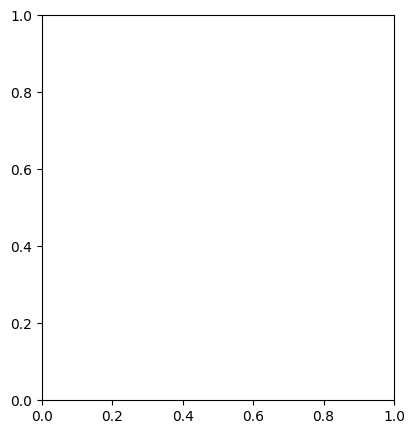

In [41]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(giants_df['j_mag'] - giants_df['h_mag'], giants_df['j_mag'] - giants_df['k_mag'], s = 1, color = 'black', label = 'giants')
plt.scatter(dwarfs_df['j_mag'] - dwarfs_df['h_mag'], dwarfs_df['j_mag'] - dwarfs_df['k_mag'], s = 1, color = 'red', label = 'dwarfs')
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel('J - H')
plt.ylabel('J - K')
plt.xlim(0,1)
plt.ylim(0,1)

plt.subplot(1,2,2)
plt.scatter(giants_df['j_mag'] - giants_df['k_mag'], giants_df['j_mag'] - giants_df['h_mag'], s = 1, color = 'black')
plt.scatter(dwarfs_df['j_mag'] - dwarfs_df['k_mag'], dwarfs_df['j_mag'] - dwarfs_df['h_mag'], s = 1, color = 'red')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('J - K')
plt.ylabel('J - H')
#plt.xlim(0,1)
#plt.ylim(0,1)

plt.tight_layout()

In [34]:
stars_labels['j-h'] = stars_labels['j_mag'] - stars_labels['h_mag']
stars_labels['h-k'] = stars_labels['h_mag'] - stars_labels['k_mag']

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/1657612873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['j-h'] = stars_labels['j_mag'] - stars_labels['h_mag']
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/1657612873.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['h-k'] = stars_labels['h_mag'] - stars_labels['k_mag']


In [35]:
stars_labels['e_j-h'] = np.maximum(
    stars_labels['e_j_mag'],
    stars_labels['e_h_mag']
)

stars_labels['e_h-k'] = np.maximum(
    stars_labels['e_h_mag'],
    stars_labels['e_k_mag']
)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/3277741314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['e_j-h'] = np.maximum(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_78966/3277741314.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stars_labels['e_h-k'] = np.maximum(


In [36]:
stars_labels['h-k'].isna().any()

np.False_

In [37]:
stars_labels['j-h'].isna().any()

np.False_

In [38]:
(stars_labels['h-k'] == '').sum()

np.int64(0)

In [47]:
(stars_labels['h-k'] > 1000).sum()

np.int64(124)

In [39]:
stars_labels['j_mag']

616284       7.396
584134       7.897
553552       8.573
72755    -9999.000
77190        7.458
            ...   
725513       9.068
405768       8.792
70443        9.175
621821       8.817
238980       8.247
Name: j_mag, Length: 2842, dtype: float32

In [60]:
giants_label_names = ['source_id', 'teff', 'e_teff', 'logg', 'e_logg', 'j-h', 'e_j-h', 'h-k', 'e_h-k']
giants_label_names += [
    col
    for el in giant_elements
    for col in (el, f"e_{el}")
]
giant_labels = stars_labels[giants_label_names]
giants_df = stars_spectra.merge(giant_labels, on='source_id', how='inner')
giants_df = giants_df[(giants_df['logg'] > 1.5) & (giants_df['logg'] < 3.5)]
giants_df = giants_df[giants_df['e_fe_h'] < 0.1]
giants_df = giants_df[giants_df['e_mg_h'] < 0.1]
giants_df = giants_df[giants_df['e_si_h'] < 0.1]
giants_df = giants_df[giants_df['e_ni_h'] < 0.1]
giants_df = giants_df[giants_df['j-h'] > 0]
giants_df = giants_df[giants_df['h-k'] > 0]
giants_df = giants_df[giants_df['j-h'] < 100]
giants_df = giants_df[giants_df['h-k'] < 100]
giants_df = giants_df[giants_df['e_j-h'] > 0]
giants_df = giants_df[giants_df['e_h-k'] > 0]
giants_df = giants_df[giants_df['e_j-h'] < 10]
giants_df = giants_df[giants_df['e_h-k'] < 10]
print("number of giants = ", len(giants_df))
print(giants_label_names)

for p in ['teff', 'logg', 'n_h', 'mg_h', 'si_h', 'fe_h', 'ni_h']:
    err_col = f"e_{p}"
    # Boolean mask of missing values (NaN)
    mask = giants_df[p].isna() | giants_df[p].astype(str).isin(['--', 'masked', '<Masked>']) | giants_df[err_col].isna() | giants_df[err_col].astype(str).isin(['--', 'masked', '<Masked>'])
    stars_masked = giants_df[~mask]
    med = np.median(stars_masked[p])
    giants_df.loc[mask, p] = med
    giants_df.loc[mask, err_col] = 9999

giants_df.to_pickle('../data/giants_feb25.pkl')

number of giants =  1581
['source_id', 'teff', 'e_teff', 'logg', 'e_logg', 'j-h', 'e_j-h', 'h-k', 'e_h-k', 'n_h', 'e_n_h', 'mg_h', 'e_mg_h', 'si_h', 'e_si_h', 'fe_h', 'e_fe_h', 'ni_h', 'e_ni_h', 'ca_h', 'e_ca_h', 'ce_h', 'e_ce_h']


In [61]:
(giants_df['e_h-k'] == 0).sum()

np.int64(0)

In [62]:
(giants_df['e_j-h'] == 0).sum()

np.int64(0)

(array([ 15.,  71., 388., 634., 354.,  93.,  15.,   9.,   1.,   1.]),
 array([0.00699997, 0.03989997, 0.07279997, 0.10569996, 0.13859996,
        0.17149997, 0.20439996, 0.23729995, 0.27019995, 0.30309996,
        0.33599997]),
 <BarContainer object of 10 artists>)

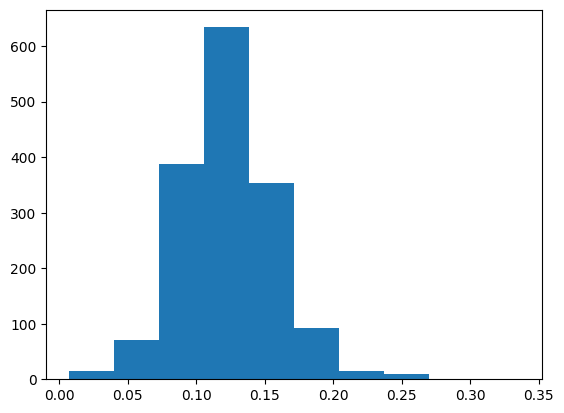

In [63]:
plt.hist(giants_df['h-k'])

In [64]:
giants_df['h-k']

0       0.068000
1       0.134000
2       0.063000
4       0.119000
5       0.092000
          ...   
2833    0.110000
2835    0.080000
2836    0.131000
2837    0.127999
2840    0.032001
Name: h-k, Length: 1581, dtype: float32

(array([1.037e+03, 5.160e+02, 2.500e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00]),
 array([0.005     , 0.0337    , 0.0624    , 0.0911    , 0.1198    ,
        0.1485    , 0.17719999, 0.2059    , 0.23459999, 0.2633    ,
        0.292     ]),
 <BarContainer object of 10 artists>)

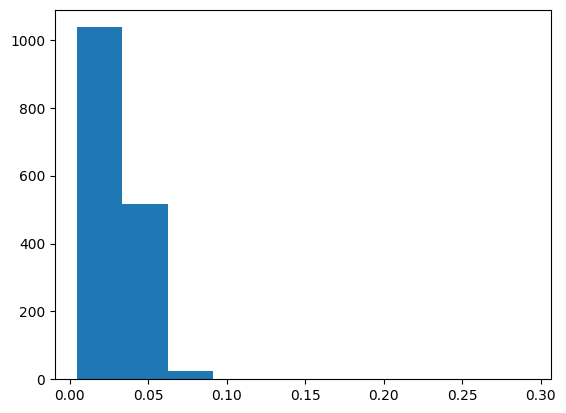

In [65]:
plt.hist(giants_df['e_h-k'])

In [45]:
(giants_df['h-k'] < 0).any()

np.False_

In [46]:
(giants_df['j-h'] < 0).any()

np.True_

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(giants_df['bp_mag'] - giants_df['rp_mag'], giants_df['M_G'], s = 1, color = 'black', label = 'giants')
plt.scatter(dwarfs_df['bp_mag'] - dwarfs_df['rp_mag'], dwarfs_df['M_G'], s = 1, color = 'red', label = 'dwarfs')
plt.gca().invert_yaxis()
plt.legend()
plt.xlabel('bp - rp')
plt.ylabel('M_G')

plt.subplot(1,2,2)
plt.scatter(np.log10(giants_df['teff']), giants_df['logg'], s = 1, color = 'black')
plt.scatter(np.log10(dwarfs_df['teff']), dwarfs_df['logg'], s = 1, color = 'red')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('log10(Teff)')
plt.ylabel('Logg')

plt.tight_layout()